In [1]:
# %% 셀 1: Imports & Config
import os
import glob
import json
import cv2
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import timm

# ──────────────────────────────────────────────
# Config
# ──────────────────────────────────────────────
PARQUET_DIR = "./data/4_is_telop_results"
FRAME_DIR = "./data/2_frame_files"
MODEL_SAVE_DIR = "./model/4_is_telop_cnn_models"

IMG_SIZE = 224
BATCH_SIZE = 256
NUM_WORKERS = 16
print(NUM_WORKERS)
LR = 3e-4
EPOCHS = 30
PATIENCE = 5
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42

os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"Device: {DEVICE}")

/home/taeyoung/miniconda3/envs/annotation/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


16
Device: cuda


In [2]:
# %% 셀 2: Dataset 정의 (멀티모달: 이미지 + 텍스트 + bbox)
def crop_rotated_region(img, cx, cy, w, h, angle, pad_ratio=0.15):
    """회전된 bbox 영역을 crop하여 정방향으로 돌린 패치를 반환."""
    h_img, w_img = img.shape[:2]
    w_pad = w * (1 + pad_ratio)
    h_pad = h * (1 + pad_ratio)

    M = cv2.getRotationMatrix2D((cx, cy), angle, 1.0)
    rotated = cv2.warpAffine(img, M, (w_img, h_img), flags=cv2.INTER_LINEAR)

    x1 = max(0, int(cx - w_pad / 2))
    y1 = max(0, int(cy - h_pad / 2))
    x2 = min(w_img, int(cx + w_pad / 2))
    y2 = min(h_img, int(cy + h_pad / 2))

    crop = rotated[y1:y2, x1:x2]
    if crop.size == 0:
        return None
    return crop


class FrameCache:
    def __init__(self, max_size=256):
        self.cache = {}
        self.order = []
        self.max_size = max_size

    def get(self, path):
        if path in self.cache:
            return self.cache[path]
        img = cv2.imread(path)
        if img is None:
            return None
        if len(self.order) >= self.max_size:
            evict = self.order.pop(0)
            self.cache.pop(evict, None)
        self.cache[path] = img
        self.order.append(path)
        return img


class CharVocab:
    """문자 단위 vocabulary. 한글/일본어/영어 모두 처리."""
    PAD = 0
    UNK = 1

    def __init__(self):
        self.char2idx = {"<PAD>": 0, "<UNK>": 1}
        self.idx2char = {0: "<PAD>", 1: "<UNK>"}

    def build(self, texts, min_freq=2):
        freq = {}
        for t in texts:
            for ch in t:
                freq[ch] = freq.get(ch, 0) + 1
        for ch, cnt in sorted(freq.items(), key=lambda x: -x[1]):
            if cnt >= min_freq:
                idx = len(self.char2idx)
                self.char2idx[ch] = idx
                self.idx2char[idx] = ch
        print(f"  Vocab size: {len(self.char2idx)} (min_freq={min_freq})")

    def encode(self, text, max_len=64):
        ids = [self.char2idx.get(ch, self.UNK) for ch in text[:max_len]]
        length = len(ids)
        ids += [self.PAD] * (max_len - length)
        return ids, length

    def __len__(self):
        return len(self.char2idx)


MAX_TEXT_LEN = 64


class TelopMultimodalDataset(Dataset):
    def __init__(self, frame_paths, cx, cy, w, h, angle, labels, texts,
                 vocab, transform=None, cache_size=256):
        self.frame_paths = frame_paths
        self.cx = cx.astype(np.float32)
        self.cy = cy.astype(np.float32)
        self.w = w.astype(np.float32)
        self.h = h.astype(np.float32)
        self.angle = angle.astype(np.float32)
        self.labels = labels.astype(np.float32)
        self.texts = texts
        self.vocab = vocab
        self.transform = transform
        self.frame_cache = FrameCache(max_size=cache_size)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # ── 이미지 crop ──
        img = self.frame_cache.get(self.frame_paths[idx])
        if img is None:
            crop = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        else:
            crop = crop_rotated_region(
                img, self.cx[idx], self.cy[idx],
                self.w[idx], self.h[idx], self.angle[idx]
            )
            if crop is None or crop.shape[0] < 4 or crop.shape[1] < 4:
                crop = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)

        crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        if self.transform:
            crop = self.transform(crop)

        # ── 텍스트 인코딩 ──
        char_ids, text_len = self.vocab.encode(self.texts[idx], MAX_TEXT_LEN)
        char_ids = torch.tensor(char_ids, dtype=torch.long)
        text_len = torch.tensor(text_len, dtype=torch.long)

        # ── bbox 피처 (정규화: cx,cy는 0~1 스케일, w,h는 상대크기) ──
        bbox = torch.tensor([
            self.cx[idx] / 1920.0,    # 대략적 정규화 (추후 실제 해상도로 조정 가능)
            self.cy[idx] / 1080.0,
            self.w[idx] / 1920.0,
            self.h[idx] / 1080.0,
            self.angle[idx] / 180.0,
        ], dtype=torch.float32)

        return crop, char_ids, text_len, bbox, self.labels[idx]


def collate_fn(batch):
    imgs, char_ids, text_lens, bboxes, labels = zip(*batch)
    imgs = torch.stack(imgs)
    char_ids = torch.stack(char_ids)
    text_lens = torch.stack(text_lens)
    bboxes = torch.stack(bboxes)
    labels = torch.tensor(labels, dtype=torch.float32)
    return imgs, char_ids, text_lens, bboxes, labels


train_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=5, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

print("✅ 멀티모달 Dataset 정의 완료")

✅ 멀티모달 Dataset 정의 완료


In [3]:
# %% 셀 3: Parquet 로드 → Vocab 구축 → Split → DataLoader
rows = []
all_texts = []

for pq_path in sorted(glob.glob(os.path.join(glob.escape(PARQUET_DIR), "*.parquet"))):
    channel = os.path.basename(pq_path)[:-8]
    df = pd.read_parquet(pq_path)

    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"📄 {channel}", leave=False):
        video_name = row["video_name"]
        frame_num = int(row["frame_num"])
        ocr_texts = json.loads(row["ocr_texts"])
        ocr_xywha = json.loads(row["ocr_xywha"])
        is_telop = json.loads(row["is_telop"])

        frame_path = os.path.join(
            FRAME_DIR, channel, video_name, f"frame_{frame_num:08d}.jpg"
        )

        for text, bbox, label in zip(ocr_texts, ocr_xywha, is_telop):
            if label is None:
                continue
            cx, cy, w, h, angle = bbox
            rows.append((frame_path, cx, cy, w, h, angle, int(label), text))
            all_texts.append(text)

# numpy 배열로 (메모리만 사용)
data = np.array(rows, dtype=object)
frame_paths = data[:, 0]
cx     = data[:, 1].astype(np.float32)
cy     = data[:, 2].astype(np.float32)
w      = data[:, 3].astype(np.float32)
h      = data[:, 4].astype(np.float32)
angle  = data[:, 5].astype(np.float32)
labels = data[:, 6].astype(np.int32)
texts  = data[:, 7]
del rows, data

n_telop = labels.sum()
n_scene = len(labels) - n_telop
print(f"\n✅ 총 {len(labels):,}건  |  telop {n_telop:,} ({n_telop/len(labels):.1%})  |  scene_text {n_scene:,}")

# Char vocab 구축
vocab = CharVocab()
vocab.build(all_texts, min_freq=2)
del all_texts

# 랜덤 split (seed=42)
indices = np.arange(len(labels))
train_idx, val_idx = train_test_split(indices, test_size=0.15, random_state=SEED, stratify=labels)

train_ds = TelopMultimodalDataset(
    frame_paths[train_idx], cx[train_idx], cy[train_idx],
    w[train_idx], h[train_idx], angle[train_idx], labels[train_idx], texts[train_idx],
    vocab=vocab, transform=train_tf,
)
val_ds = TelopMultimodalDataset(
    frame_paths[val_idx], cx[val_idx], cy[val_idx],
    w[val_idx], h[val_idx], angle[val_idx], labels[val_idx], texts[val_idx],
    vocab=vocab, transform=val_tf,
)

print(f"Train: {len(train_ds):,}건  |  Val: {len(val_ds):,}건")

# Class-balanced sampler
train_labels = labels[train_idx]
class_counts = np.bincount(train_labels)
sample_weights = (1.0 / class_counts)[train_labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, sampler=sampler,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
    persistent_workers=True if NUM_WORKERS > 0 else False,
    collate_fn=collate_fn,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
    persistent_workers=True if NUM_WORKERS > 0 else False,
    collate_fn=collate_fn,
)

print("✅ DataLoader 준비 완료")


✅ 총 1,149,314건  |  telop 985,967 (85.8%)  |  scene_text 163,347
  Vocab size: 1709 (min_freq=2)
Train: 976,916건  |  Val: 172,398건
✅ DataLoader 준비 완료


In [4]:
# %% 셀 4: 멀티모달 모델 정의
class TextEncoder(nn.Module):
    """Char-CNN + BiGRU 텍스트 인코더."""
    def __init__(self, vocab_size, embed_dim=64, cnn_out=128, gru_hidden=64):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.cnn = nn.Sequential(
            nn.Conv1d(embed_dim, cnn_out, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(cnn_out, cnn_out, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.gru = nn.GRU(cnn_out, gru_hidden, batch_first=True, bidirectional=True)
        self.out_dim = gru_hidden * 2  # bidirectional

    def forward(self, char_ids, text_lens):
        # char_ids: (B, max_len), text_lens: (B,)
        x = self.embed(char_ids)                     # (B, L, embed_dim)
        x = x.transpose(1, 2)                        # (B, embed_dim, L)
        x = self.cnn(x)                              # (B, cnn_out, L)
        x = x.transpose(1, 2)                        # (B, L, cnn_out)

        # pack → GRU → unpack
        packed = nn.utils.rnn.pack_padded_sequence(
            x, text_lens.cpu().clamp(min=1), batch_first=True, enforce_sorted=False
        )
        _, hidden = self.gru(packed)                  # hidden: (2, B, gru_hidden)
        # 양방향 concat
        out = torch.cat([hidden[0], hidden[1]], dim=-1)  # (B, gru_hidden*2)
        return out


class BboxMLP(nn.Module):
    """bbox 좌표 인코더."""
    def __init__(self, in_dim=5, hidden=64, out_dim=32):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, out_dim),
            nn.ReLU(),
        )

    def forward(self, bbox):
        return self.mlp(bbox)


class TelopMultimodalClassifier(nn.Module):
    def __init__(self, vocab_size, text_out=128, bbox_out=32, fusion_hidden=256):
        super().__init__()
        # ── 이미지 브랜치: EfficientNet-B0 ──
        self.image_enc = timm.create_model("efficientnet_b0", pretrained=True, num_classes=0)
        img_feat_dim = 1280

        # ── 텍스트 브랜치: Char-CNN + BiGRU ──
        self.text_enc = TextEncoder(vocab_size, embed_dim=64, cnn_out=128, gru_hidden=text_out // 2)
        text_feat_dim = self.text_enc.out_dim

        # ── bbox 브랜치 ──
        self.bbox_enc = BboxMLP(in_dim=5, hidden=64, out_dim=bbox_out)

        # ── Fusion MLP ──
        total_dim = img_feat_dim + text_feat_dim + bbox_out
        self.fusion = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(total_dim, fusion_hidden),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(fusion_hidden, 1),
        )

    def forward(self, imgs, char_ids, text_lens, bboxes):
        img_feat = self.image_enc(imgs)                    # (B, 1280)
        text_feat = self.text_enc(char_ids, text_lens)     # (B, text_out)
        bbox_feat = self.bbox_enc(bboxes)                  # (B, bbox_out)

        fused = torch.cat([img_feat, text_feat, bbox_feat], dim=-1)
        return self.fusion(fused)                          # (B, 1)


model = TelopMultimodalClassifier(vocab_size=len(vocab)).to(DEVICE)

n_pos = train_labels.sum()
n_neg = len(train_labels) - n_pos
pos_weight = torch.tensor([n_neg / max(n_pos, 1)], device=DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

total_params = sum(p.numel() for p in model.parameters())
print(f"✅ 멀티모달 모델 로드 완료  |  pos_weight={pos_weight.item():.2f}")
print(f"   파라미터 수: {total_params:,}")
print(f"   - 이미지: {sum(p.numel() for p in model.image_enc.parameters()):,}")
print(f"   - 텍스트: {sum(p.numel() for p in model.text_enc.parameters()):,}")
print(f"   - bbox:   {sum(p.numel() for p in model.bbox_enc.parameters()):,}")
print(f"   - fusion: {sum(p.numel() for p in model.fusion.parameters()):,}")

✅ 멀티모달 모델 로드 완료  |  pos_weight=0.17
   파라미터 수: 4,637,021
   - 이미지: 4,007,548
   - 텍스트: 257,856
   - bbox:   2,464
   - fusion: 369,153


In [5]:
# %% 셀 5: 학습 루프
use_amp = DEVICE == "cuda"
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

best_f1 = 0.0
patience_counter = 0
history = {"train_loss": [], "val_loss": [], "val_f1": [], "val_prec": [], "val_rec": []}

for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    model.train()
    running_loss = 0.0
    n_samples = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [Train]", leave=False)
    for imgs, char_ids, text_lens, bboxes, labels_batch in pbar:
        imgs = imgs.to(DEVICE, non_blocking=True)
        char_ids = char_ids.to(DEVICE, non_blocking=True)
        text_lens = text_lens.to(DEVICE, non_blocking=True)
        bboxes = bboxes.to(DEVICE, non_blocking=True)
        labels_batch = labels_batch.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=use_amp):
            logits = model(imgs, char_ids, text_lens, bboxes).squeeze(-1)
            loss = criterion(logits, labels_batch)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * imgs.size(0)
        n_samples += imgs.size(0)
        pbar.set_postfix(loss=f"{running_loss/n_samples:.4f}")

    train_loss = running_loss / n_samples
    scheduler.step()

    # ── Validation ──
    model.eval()
    all_preds, all_labels = [], []
    val_loss = 0.0
    n_val = 0
    with torch.no_grad():
        pbar_val = tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} [Val]", leave=False)
        for imgs, char_ids, text_lens, bboxes, labels_batch in pbar_val:
            imgs = imgs.to(DEVICE, non_blocking=True)
            char_ids = char_ids.to(DEVICE, non_blocking=True)
            text_lens = text_lens.to(DEVICE, non_blocking=True)
            bboxes = bboxes.to(DEVICE, non_blocking=True)
            labels_batch = labels_batch.to(DEVICE, non_blocking=True)

            with torch.amp.autocast("cuda", enabled=use_amp):
                logits = model(imgs, char_ids, text_lens, bboxes).squeeze(-1)
                loss = criterion(logits, labels_batch)

            val_loss += loss.item() * imgs.size(0)
            n_val += imgs.size(0)
            pbar_val.set_postfix(loss=f"{val_loss/n_val:.4f}")

            preds = (torch.sigmoid(logits) >= 0.5).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels_batch.cpu().numpy())

    val_loss /= n_val
    f1 = f1_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec = recall_score(all_labels, all_preds, zero_division=0)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_f1"].append(f1)
    history["val_prec"].append(prec)
    history["val_rec"].append(rec)

    lr_now = optimizer.param_groups[0]["lr"]
    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
        f"F1={f1:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | LR={lr_now:.2e}"
    )

    # ── Early Stopping & Checkpoint ──
    # 매 에포크 저장
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "vocab_char2idx": vocab.char2idx,
        "f1": f1,
    }, os.path.join(MODEL_SAVE_DIR, f"epoch_{epoch:02d}_f1_{f1:.4f}.pth"))

    if f1 > best_f1:
        best_f1 = f1
        patience_counter = 0
        print(f"  💾 Best (F1={best_f1:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"  ⏹ Early stopping at epoch {epoch}")
            break
print(f"\n🏆 Best Val F1: {best_f1:.4f}")

/tmp/ipykernel_1040795/3067968415.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


Epoch 01 | train_loss=0.0762 | val_loss=0.0788 | F1=0.9005 | Prec=0.9963 | Rec=0.8215 | LR=2.99e-04
  💾 Best (F1=0.9005)


Epoch 02 | train_loss=0.0579 | val_loss=0.0742 | F1=0.9176 | Prec=0.9955 | Rec=0.8510 | LR=2.97e-04
  💾 Best (F1=0.9176)


Epoch 03 | train_loss=0.0512 | val_loss=0.0727 | F1=0.9300 | Prec=0.9939 | Rec=0.8738 | LR=2.93e-04
  💾 Best (F1=0.9300)


Epoch 04 | train_loss=0.0463 | val_loss=0.0745 | F1=0.9229 | Prec=0.9956 | Rec=0.8600 | LR=2.87e-04


...

Epoch 26 | train_loss=0.0086 | val_loss=0.2180 | F1=0.9647 | Prec=0.9751 | Rec=0.9544 | LR=1.30e-05
  💾 Best (F1=0.9647)


Epoch 27 | train_loss=0.0084 | val_loss=0.2242 | F1=0.9647 | Prec=0.9744 | Rec=0.9551 | LR=7.34e-06


Epoch 28 | train_loss=0.0080 | val_loss=0.2293 | F1=0.9649 | Prec=0.9740 | Rec=0.9560 | LR=3.28e-06
  💾 Best (F1=0.9649)


Epoch 29 | train_loss=0.0078 | val_loss=0.2346 | F1=0.9652 | Prec=0.9734 | Rec=0.9572 | LR=8.22e-07
  💾 Best (F1=0.9652)


Epoch 30 | train_loss=0.0076 | val_loss=0.2362 | F1=0.9651 | Prec=0.9732 | Rec=0.9572 | LR=0.00e+00

🏆 Best Val F1: 0.9652


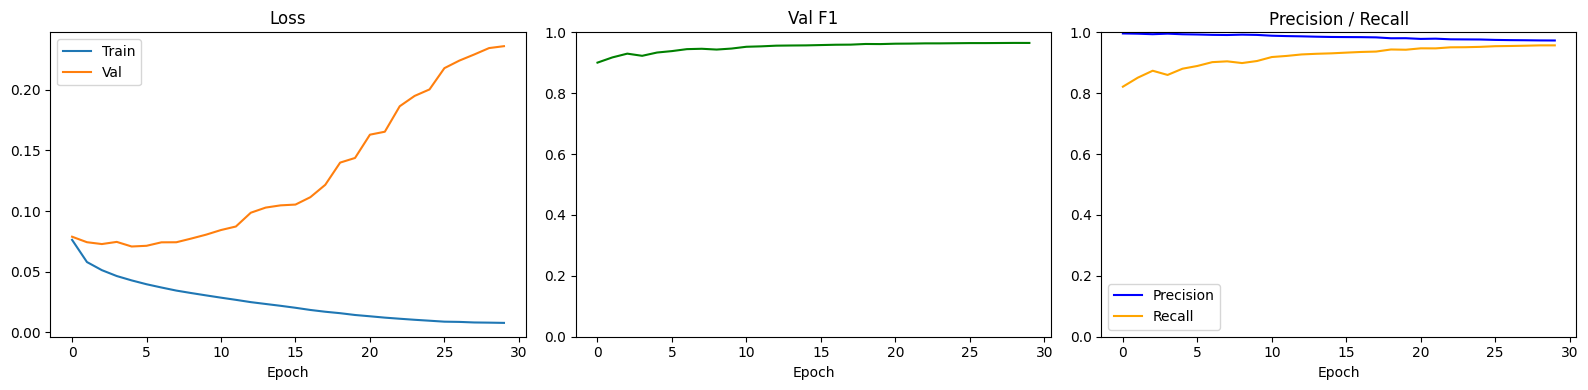

✅ 학습 곡선 저장 완료
📦 로드: epoch_29_f1_0.9652.pth
오분류: 10200건 / 172398건 (5.9%)


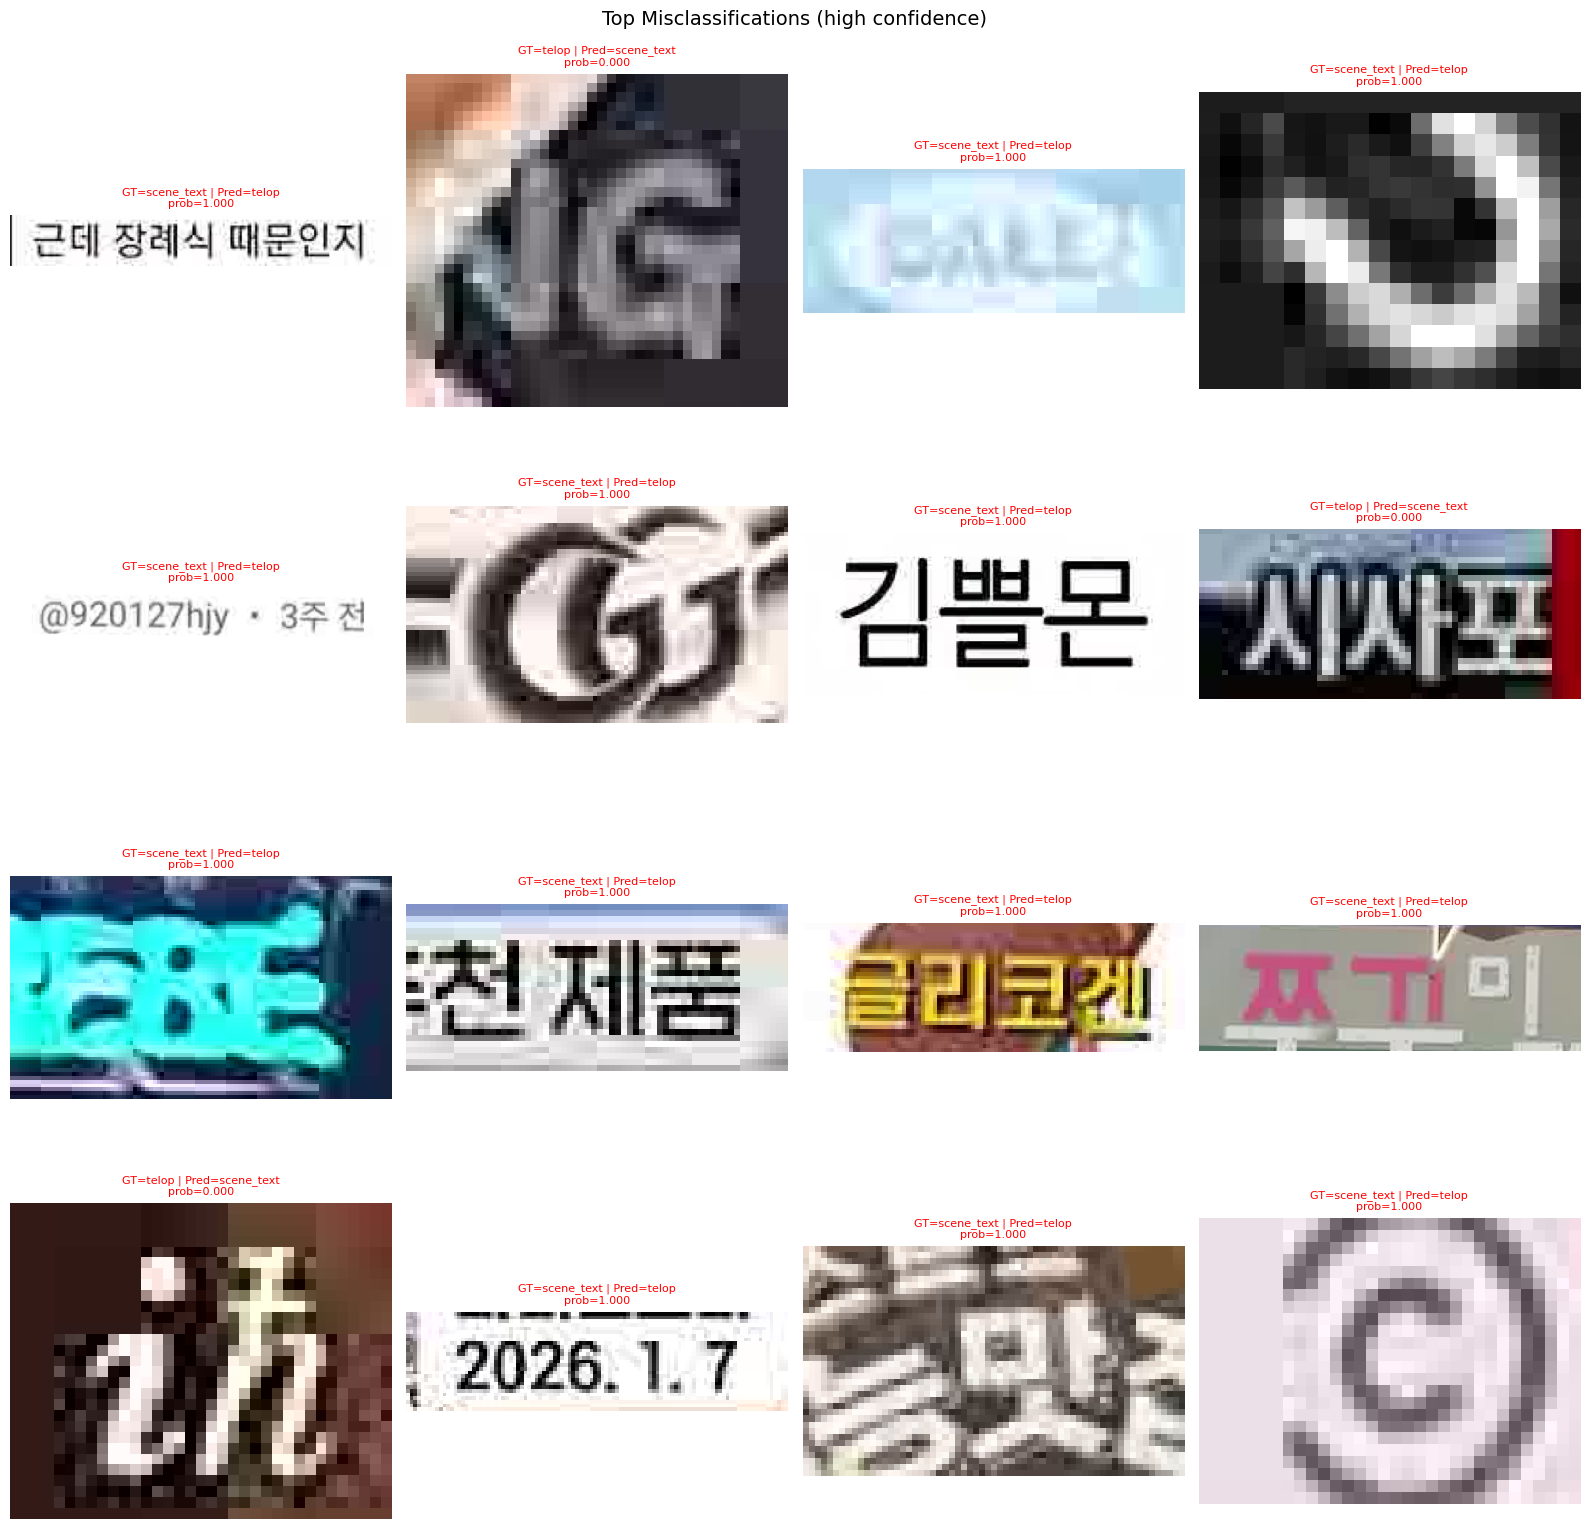

In [8]:
# %% 셀 6: 학습 곡선 시각화
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"], label="Val")
axes[0].set_title("Loss")
axes[0].legend()
axes[0].set_xlabel("Epoch")

axes[1].plot(history["val_f1"], label="F1", color="green")
axes[1].set_title("Val F1")
axes[1].set_xlabel("Epoch")
axes[1].set_ylim(0, 1)

axes[2].plot(history["val_prec"], label="Precision", color="blue")
axes[2].plot(history["val_rec"], label="Recall", color="orange")
axes[2].set_title("Precision / Recall")
axes[2].legend()
axes[2].set_xlabel("Epoch")
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, "training_curves.png"), dpi=150)
plt.show()
print("✅ 학습 곡선 저장 완료")


# %% 셀 7: 오분류 샘플 시각화

# 가장 높은 F1 checkpoint 찾기
import re
ckpt_files = [f for f in os.listdir(MODEL_SAVE_DIR) if f.startswith("epoch_") and f.endswith(".pth")]
best_ckpt = max(ckpt_files, key=lambda f: float(re.search(r"f1_([\d.]+)\.pth", f).group(1)))
print(f"📦 로드: {best_ckpt}")

ckpt = torch.load(os.path.join(MODEL_SAVE_DIR, best_ckpt), map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

all_preds, all_probs, all_labels_vis = [], [], []
with torch.no_grad():
    for batch in val_loader:
        imgs = batch[0].to(DEVICE)
        char_ids = batch[1].to(DEVICE)
        text_lens = batch[2].to(DEVICE)
        bboxes = batch[3].to(DEVICE)
        labels_batch = batch[4]

        with torch.amp.autocast("cuda", enabled=use_amp):
            logits = model(imgs, char_ids, text_lens, bboxes).squeeze(-1)

        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs >= 0.5).astype(int)
        all_preds.extend(preds)
        all_probs.extend(probs)
        all_labels_vis.extend(labels_batch.numpy().astype(int))

errors = [
    (i, all_labels_vis[i], all_preds[i], all_probs[i])
    for i in range(len(all_labels_vis))
    if all_labels_vis[i] != all_preds[i]
]
print(f"오분류: {len(errors)}건 / {len(all_labels_vis)}건 ({len(errors)/len(all_labels_vis):.1%})")

# 확신 높은 오분류 순 정렬
errors.sort(key=lambda x: abs(x[3] - 0.5), reverse=True)
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
label_names = {0: "scene_text", 1: "telop"}

for ax, (idx, gt, pred, prob) in zip(axes.flat, errors[:16]):
    fp = val_ds.frame_paths[idx]
    frame = cv2.imread(fp)
    if frame is not None:
        crop = crop_rotated_region(
            frame, val_ds.cx[idx], val_ds.cy[idx],
            val_ds.w[idx], val_ds.h[idx], val_ds.angle[idx]
        )
        if crop is not None:
            crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
            ax.imshow(crop)
    ax.set_title(
        f"GT={label_names[gt]} | Pred={label_names[pred]}\nprob={prob:.3f}",
        fontsize=8, color="red"
    )
    ax.axis("off")

plt.suptitle("Top Misclassifications (high confidence)", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, "misclassifications.png"), dpi=150)
plt.show()

In [1]:
# %% 셀 8: Gradio 인터랙티브 시각화 (독립 실행, lazy loading)
import os
import glob
import json
import random
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torchvision import transforms
import timm
import gradio as gr

# ──────────────────────────────────────────────
# Config
# ──────────────────────────────────────────────
OCR_PARQUET_DIR = "./data/3_ocr_results"
FRAME_DIR = "./data/2_frame_files"
MODEL_SAVE_DIR = "./model/4_is_telop_cnn_models"
CKPT_NAME = "epoch_08_f1_0.9460.pth"

IMG_SIZE = 224
MAX_TEXT_LEN = 64
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ──────────────────────────────────────────────
# 모델 정의
# ──────────────────────────────────────────────
class CharVocab:
    PAD = 0
    UNK = 1

    def __init__(self, char2idx=None):
        self.char2idx = char2idx or {"<PAD>": 0, "<UNK>": 1}

    def encode(self, text, max_len=64):
        ids = [self.char2idx.get(ch, self.UNK) for ch in str(text)[:max_len]]
        length = len(ids)
        ids += [self.PAD] * (max_len - length)
        return ids, length

    def __len__(self):
        return len(self.char2idx)


class TextEncoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, cnn_out=128, gru_hidden=64):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.cnn = nn.Sequential(
            nn.Conv1d(embed_dim, cnn_out, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(cnn_out, cnn_out, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.gru = nn.GRU(cnn_out, gru_hidden, batch_first=True, bidirectional=True)
        self.out_dim = gru_hidden * 2

    def forward(self, char_ids, text_lens):
        x = self.embed(char_ids)
        x = x.transpose(1, 2)
        x = self.cnn(x)
        x = x.transpose(1, 2)
        packed = nn.utils.rnn.pack_padded_sequence(
            x, text_lens.cpu().clamp(min=1), batch_first=True, enforce_sorted=False
        )
        _, hidden = self.gru(packed)
        out = torch.cat([hidden[0], hidden[1]], dim=-1)
        return out


class BboxMLP(nn.Module):
    def __init__(self, in_dim=5, hidden=64, out_dim=32):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, out_dim), nn.ReLU(),
        )

    def forward(self, bbox):
        return self.mlp(bbox)


class TelopMultimodalClassifier(nn.Module):
    def __init__(self, vocab_size, text_out=128, bbox_out=32, fusion_hidden=256):
        super().__init__()
        self.image_enc = timm.create_model("efficientnet_b0", pretrained=False, num_classes=0)
        img_feat_dim = 1280
        self.text_enc = TextEncoder(vocab_size, embed_dim=64, cnn_out=128, gru_hidden=text_out // 2)
        text_feat_dim = self.text_enc.out_dim
        self.bbox_enc = BboxMLP(in_dim=5, hidden=64, out_dim=bbox_out)
        total_dim = img_feat_dim + text_feat_dim + bbox_out
        self.fusion = nn.Sequential(
            nn.Dropout(0.3), nn.Linear(total_dim, fusion_hidden), nn.ReLU(),
            nn.Dropout(0.2), nn.Linear(fusion_hidden, 1),
        )

    def forward(self, imgs, char_ids, text_lens, bboxes):
        img_feat = self.image_enc(imgs)
        text_feat = self.text_enc(char_ids, text_lens)
        bbox_feat = self.bbox_enc(bboxes)
        fused = torch.cat([img_feat, text_feat, bbox_feat], dim=-1)
        return self.fusion(fused)


def crop_rotated_region(img, cx, cy, w, h, angle, pad_ratio=0.15):
    h_img, w_img = img.shape[:2]
    w_pad = w * (1 + pad_ratio)
    h_pad = h * (1 + pad_ratio)
    M = cv2.getRotationMatrix2D((cx, cy), angle, 1.0)
    rotated = cv2.warpAffine(img, M, (w_img, h_img), flags=cv2.INTER_LINEAR)
    x1 = max(0, int(cx - w_pad / 2))
    y1 = max(0, int(cy - h_pad / 2))
    x2 = min(w_img, int(cx + w_pad / 2))
    y2 = min(h_img, int(cy + h_pad / 2))
    crop = rotated[y1:y2, x1:x2]
    if crop.size == 0:
        return None
    return crop


# ──────────────────────────────────────────────
# 모델 & vocab 로드
# ──────────────────────────────────────────────
ckpt_path = os.path.join(MODEL_SAVE_DIR, CKPT_NAME)
ckpt = torch.load(ckpt_path, map_location=DEVICE)

vocab = CharVocab(char2idx=ckpt["vocab_char2idx"])
model = TelopMultimodalClassifier(vocab_size=len(vocab)).to(DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"✅ 모델 로드: {CKPT_NAME}")

val_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# ──────────────────────────────────────────────
# parquet 경로 목록만 수집 (데이터는 안 읽음)
# ──────────────────────────────────────────────
parquet_index = []  # [(channel, video_name, parquet_path), ...]

for channel_entry in sorted(os.scandir(OCR_PARQUET_DIR), key=lambda e: e.name):
    if not channel_entry.is_dir():
        continue
    channel = channel_entry.name
    for pq_path in sorted(glob.glob(os.path.join(glob.escape(channel_entry.path), "*.parquet"))):
        video_name = os.path.basename(pq_path)[:-8]
        parquet_index.append((channel, video_name, pq_path))

print(f"✅ parquet 인덱스: {len(parquet_index)}개 (데이터 미로드)")


# ──────────────────────────────────────────────
# 버튼 클릭 시 실행: parquet 읽기 → 랜덤 프레임 → 추론 → 시각화
# ──────────────────────────────────────────────
def predict_and_draw(threshold=0.5):
    # 1) 랜덤 parquet 선택 → 읽기
    channel, video_name, pq_path = random.choice(parquet_index)
    df = pd.read_parquet(pq_path)

    # 2) 랜덤 프레임 선택
    row = df.sample(1).iloc[0]
    frame_num = int(row["frame_num"])
    ocr_texts = json.loads(row["ocr_texts"]) if isinstance(row["ocr_texts"], str) else row["ocr_texts"]
    ocr_xywha = json.loads(row["ocr_xywha"]) if isinstance(row["ocr_xywha"], str) else row["ocr_xywha"]

    if not ocr_texts:
        return None, "OCR 텍스트 없는 프레임 — 다시 눌러주세요"

    frame_path = os.path.join(FRAME_DIR, channel, video_name, f"frame_{frame_num:08d}.jpg")
    frame = cv2.imread(frame_path)
    if frame is None:
        return None, f"프레임 로드 실패: {frame_path}"

    display = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB).copy()

    # 3) 각 region 준비
    crops_list = []
    char_ids_list = []
    text_lens_list = []
    bboxes_list = []
    valid_regions = []

    for text, bbox in zip(ocr_texts, ocr_xywha):
        cx, cy, w, h, angle = bbox
        crop = crop_rotated_region(frame, cx, cy, w, h, angle)
        if crop is None or crop.shape[0] < 4 or crop.shape[1] < 4:
            continue

        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        crops_list.append(val_tf(crop_rgb))

        char_id, text_len = vocab.encode(text, MAX_TEXT_LEN)
        char_ids_list.append(torch.tensor(char_id, dtype=torch.long))
        text_lens_list.append(torch.tensor(text_len, dtype=torch.long))

        bboxes_list.append(torch.tensor([
            cx / 1920.0, cy / 1080.0,
            w / 1920.0, h / 1080.0,
            angle / 180.0,
        ], dtype=torch.float32))

        valid_regions.append((str(text or ""), cx, cy, w, h, angle))

    if not crops_list:
        return None, "유효한 region 없음 — 다시 눌러주세요"

    # 4) 배치 추론
    batch_imgs = torch.stack(crops_list).to(DEVICE)
    batch_char_ids = torch.stack(char_ids_list).to(DEVICE)
    batch_text_lens = torch.stack(text_lens_list).to(DEVICE)
    batch_bboxes = torch.stack(bboxes_list).to(DEVICE)

    with torch.no_grad():
        with torch.amp.autocast("cuda", enabled=(DEVICE == "cuda")):
            logits = model(batch_imgs, batch_char_ids, batch_text_lens, batch_bboxes).squeeze(-1)
        probs = torch.sigmoid(logits).cpu().numpy()

    # 5) bbox 그리기
    info_lines = []
    for i, (text, cx, cy, w, h, angle) in enumerate(valid_regions):
        prob = probs[i]
        is_telop = prob >= threshold

        color = (0, 0, 255) if is_telop else (255, 0, 0)

        rect = ((cx, cy), (w, h), angle)
        box = cv2.boxPoints(rect).astype(int)
        cv2.drawContours(display, [box], 0, color, 2)

        tag = "telop" if is_telop else "scene"
        label_text = f"{tag} {prob:.2f}"
        tx, ty = int(cx - w / 2), int(cy - h / 2) - 8
        (tw, th_), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(display, (tx, ty - th_ - 4), (tx + tw + 4, ty + 2), color, -1)
        cv2.putText(display, label_text, (tx + 2, ty), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

        info_lines.append(f"[{tag}] p={prob:.3f} | {text[:40]}")

    info_text = f"채널: {channel}\n영상: {video_name}\n프레임: {frame_num}\nthreshold: {threshold}\nregions: {len(valid_regions)}\n\n"
    info_text += "\n".join(info_lines)

    return display, info_text


# ──────────────────────────────────────────────
# Gradio UI
# ──────────────────────────────────────────────
with gr.Blocks(title="Telop Classifier Viewer") as demo:
    gr.Markdown("## Telop / Scene Text 분류 결과 뷰어")
    gr.Markdown("🟦 cyan bbox = Telop  |  🟥 red bbox = Scene Text")

    with gr.Row():
        threshold_slider = gr.Slider(0.1, 0.9, value=0.5, step=0.05, label="Threshold")
        btn = gr.Button("🎲 랜덤 프레임", variant="primary", scale=0)

    with gr.Row():
        img_out = gr.Image(label="결과", height=1280, scale=3)
        info_out = gr.Textbox(label="상세 정보", lines=20)

    btn.click(fn=predict_and_draw, inputs=[threshold_slider], outputs=[img_out, info_out])

demo.launch(share=False, server_name="0.0.0.0", server_port=7860)

/home/taeyoung/miniconda3/envs/annotation/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ 모델 로드: epoch_08_f1_0.9460.pth
✅ parquet 인덱스: 66392개 (데이터 미로드)
* Running on local URL:  http://0.0.0.0:7860
* To create a public link, set `share=True` in `launch()`.


In [1]:
# %% 셀 8: Gradio 인터랙티브 시각화 (독립 실행, lazy loading)
import os
import glob
import json
import random
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torchvision import transforms
import timm
import gradio as gr

# ──────────────────────────────────────────────
# Config
# ──────────────────────────────────────────────
OCR_PARQUET_DIR = "./data/3_ocr_results"
FRAME_DIR = "./data/2_frame_files"
MODEL_SAVE_DIR = "./model/4_is_telop_cnn_models"
CKPT_NAME = "epoch_08_f1_0.9460.pth"

IMG_SIZE = 224
MAX_TEXT_LEN = 64
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ──────────────────────────────────────────────
# 모델 정의
# ──────────────────────────────────────────────
class CharVocab:
    PAD = 0
    UNK = 1

    def __init__(self, char2idx=None):
        self.char2idx = char2idx or {"<PAD>": 0, "<UNK>": 1}

    def encode(self, text, max_len=64):
        ids = [self.char2idx.get(ch, self.UNK) for ch in str(text)[:max_len]]
        length = len(ids)
        ids += [self.PAD] * (max_len - length)
        return ids, length

    def __len__(self):
        return len(self.char2idx)


class TextEncoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, cnn_out=128, gru_hidden=64):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.cnn = nn.Sequential(
            nn.Conv1d(embed_dim, cnn_out, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(cnn_out, cnn_out, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.gru = nn.GRU(cnn_out, gru_hidden, batch_first=True, bidirectional=True)
        self.out_dim = gru_hidden * 2

    def forward(self, char_ids, text_lens):
        x = self.embed(char_ids)
        x = x.transpose(1, 2)
        x = self.cnn(x)
        x = x.transpose(1, 2)
        packed = nn.utils.rnn.pack_padded_sequence(
            x, text_lens.cpu().clamp(min=1), batch_first=True, enforce_sorted=False
        )
        _, hidden = self.gru(packed)
        out = torch.cat([hidden[0], hidden[1]], dim=-1)
        return out


class BboxMLP(nn.Module):
    def __init__(self, in_dim=5, hidden=64, out_dim=32):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, out_dim), nn.ReLU(),
        )

    def forward(self, bbox):
        return self.mlp(bbox)


class TelopMultimodalClassifier(nn.Module):
    def __init__(self, vocab_size, text_out=128, bbox_out=32, fusion_hidden=256):
        super().__init__()
        self.image_enc = timm.create_model("efficientnet_b0", pretrained=False, num_classes=0)
        img_feat_dim = 1280
        self.text_enc = TextEncoder(vocab_size, embed_dim=64, cnn_out=128, gru_hidden=text_out // 2)
        text_feat_dim = self.text_enc.out_dim
        self.bbox_enc = BboxMLP(in_dim=5, hidden=64, out_dim=bbox_out)
        total_dim = img_feat_dim + text_feat_dim + bbox_out
        self.fusion = nn.Sequential(
            nn.Dropout(0.3), nn.Linear(total_dim, fusion_hidden), nn.ReLU(),
            nn.Dropout(0.2), nn.Linear(fusion_hidden, 1),
        )

    def forward(self, imgs, char_ids, text_lens, bboxes):
        img_feat = self.image_enc(imgs)
        text_feat = self.text_enc(char_ids, text_lens)
        bbox_feat = self.bbox_enc(bboxes)
        fused = torch.cat([img_feat, text_feat, bbox_feat], dim=-1)
        return self.fusion(fused)


def crop_rotated_region(img, cx, cy, w, h, angle, pad_ratio=0.15):
    h_img, w_img = img.shape[:2]
    w_pad = w * (1 + pad_ratio)
    h_pad = h * (1 + pad_ratio)
    M = cv2.getRotationMatrix2D((cx, cy), angle, 1.0)
    rotated = cv2.warpAffine(img, M, (w_img, h_img), flags=cv2.INTER_LINEAR)
    x1 = max(0, int(cx - w_pad / 2))
    y1 = max(0, int(cy - h_pad / 2))
    x2 = min(w_img, int(cx + w_pad / 2))
    y2 = min(h_img, int(cy + h_pad / 2))
    crop = rotated[y1:y2, x1:x2]
    if crop.size == 0:
        return None
    return crop


# ──────────────────────────────────────────────
# 모델 & vocab 로드
# ──────────────────────────────────────────────
ckpt_path = os.path.join(MODEL_SAVE_DIR, CKPT_NAME)
ckpt = torch.load(ckpt_path, map_location=DEVICE)

vocab = CharVocab(char2idx=ckpt["vocab_char2idx"])
model = TelopMultimodalClassifier(vocab_size=len(vocab)).to(DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"✅ 모델 로드: {CKPT_NAME}")

val_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# ──────────────────────────────────────────────
# parquet 경로 목록만 수집 (데이터는 안 읽음)
# ──────────────────────────────────────────────
parquet_index = []  # [(channel, video_name, parquet_path), ...]

for channel_entry in sorted(os.scandir(OCR_PARQUET_DIR), key=lambda e: e.name):
    if not channel_entry.is_dir():
        continue
    channel = channel_entry.name
    for pq_path in sorted(glob.glob(os.path.join(glob.escape(channel_entry.path), "*.parquet"))):
        video_name = os.path.basename(pq_path)[:-8]
        parquet_index.append((channel, video_name, pq_path))

print(f"✅ parquet 인덱스: {len(parquet_index)}개 (데이터 미로드)")

# ──────────────────────────────────────────────
# 폴더 경로 기반 필터링 유틸
# ──────────────────────────────────────────────
def filter_parquet_index(folder_input: str):
    """
    folder_input 에 따라 parquet_index를 필터링.
    - 빈 문자열 / None → 전체
    - "채널명"           → 해당 채널의 모든 영상
    - "채널명/영상명"     → 해당 영상만
    """
    folder_input = (folder_input or "").strip().strip("/")

    if not folder_input:
        return parquet_index  # 전체

    parts = folder_input.split("/", 1)

    if len(parts) == 1:
        # 채널명만 입력
        target_channel = parts[0]
        filtered = [
            (ch, vn, pp) for ch, vn, pp in parquet_index
            if ch == target_channel
        ]
    else:
        # 채널명/영상명
        target_channel, target_video = parts
        filtered = [
            (ch, vn, pp) for ch, vn, pp in parquet_index
            if ch == target_channel and vn == target_video
        ]

    return filtered


# ──────────────────────────────────────────────
# 버튼 클릭 시 실행: parquet 읽기 → 랜덤 프레임 → 추론 → 시각화
# ──────────────────────────────────────────────
def predict_and_draw(folder_input, threshold=0.5):
    # 0) 폴더 필터링
    candidates = filter_parquet_index(folder_input)
    if not candidates:
        return None, f"❌ 해당 폴더에 매칭되는 parquet이 없습니다: '{folder_input}'\n\n" \
                      f"입력 형식:\n  - 비워두기 → 전체 랜덤\n  - 채널명 → 채널 내 랜덤\n  - 채널명/영상명 → 해당 영상 내 랜덤"

    # 1) 랜덤 parquet 선택 → 읽기
    channel, video_name, pq_path = random.choice(candidates)
    df = pd.read_parquet(pq_path)

    # 2) 랜덤 프레임 선택
    row = df.sample(1).iloc[0]
    frame_num = int(row["frame_num"])
    ocr_texts = json.loads(row["ocr_texts"]) if isinstance(row["ocr_texts"], str) else row["ocr_texts"]
    ocr_xywha = json.loads(row["ocr_xywha"]) if isinstance(row["ocr_xywha"], str) else row["ocr_xywha"]

    if not ocr_texts:
        return None, "OCR 텍스트 없는 프레임 — 다시 눌러주세요"

    frame_path = os.path.join(FRAME_DIR, channel, video_name, f"frame_{frame_num:08d}.jpg")
    frame = cv2.imread(frame_path)
    if frame is None:
        return None, f"프레임 로드 실패: {frame_path}"

    display = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB).copy()

    # 3) 각 region 준비
    crops_list = []
    char_ids_list = []
    text_lens_list = []
    bboxes_list = []
    valid_regions = []

    for text, bbox in zip(ocr_texts, ocr_xywha):
        cx, cy, w, h, angle = bbox
        crop = crop_rotated_region(frame, cx, cy, w, h, angle)
        if crop is None or crop.shape[0] < 4 or crop.shape[1] < 4:
            continue

        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        crops_list.append(val_tf(crop_rgb))

        char_id, text_len = vocab.encode(text, MAX_TEXT_LEN)
        char_ids_list.append(torch.tensor(char_id, dtype=torch.long))
        text_lens_list.append(torch.tensor(text_len, dtype=torch.long))

        bboxes_list.append(torch.tensor([
            cx / 1920.0, cy / 1080.0,
            w / 1920.0, h / 1080.0,
            angle / 180.0,
        ], dtype=torch.float32))

        valid_regions.append((str(text or ""), cx, cy, w, h, angle))

    if not crops_list:
        return None, "유효한 region 없음 — 다시 눌러주세요"

    # 4) 배치 추론
    batch_imgs = torch.stack(crops_list).to(DEVICE)
    batch_char_ids = torch.stack(char_ids_list).to(DEVICE)
    batch_text_lens = torch.stack(text_lens_list).to(DEVICE)
    batch_bboxes = torch.stack(bboxes_list).to(DEVICE)

    with torch.no_grad():
        with torch.amp.autocast("cuda", enabled=(DEVICE == "cuda")):
            logits = model(batch_imgs, batch_char_ids, batch_text_lens, batch_bboxes).squeeze(-1)
        probs = torch.sigmoid(logits).cpu().numpy()

    # 5) bbox 그리기
    info_lines = []
    for i, (text, cx, cy, w, h, angle) in enumerate(valid_regions):
        prob = probs[i]
        is_telop = prob >= threshold

        color = (0, 0, 255) if is_telop else (255, 0, 0)

        rect = ((cx, cy), (w, h), angle)
        box = cv2.boxPoints(rect).astype(int)
        cv2.drawContours(display, [box], 0, color, 2)

        tag = "telop" if is_telop else "scene"
        label_text = f"{tag} {prob:.2f}"
        tx, ty = int(cx - w / 2), int(cy - h / 2) - 8
        (tw, th_), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(display, (tx, ty - th_ - 4), (tx + tw + 4, ty + 2), color, -1)
        cv2.putText(display, label_text, (tx + 2, ty), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

        info_lines.append(f"[{tag}] p={prob:.3f} | {text[:40]}")

    filter_info = f"필터: {folder_input if folder_input else '전체 (랜덤)'}\n"
    info_text = (
        f"{filter_info}"
        f"채널: {channel}\n"
        f"영상: {video_name}\n"
        f"프레임: {frame_num}\n"
        f"threshold: {threshold}\n"
        f"regions: {len(valid_regions)}\n\n"
    )
    info_text += "\n".join(info_lines)

    return display, info_text


# ──────────────────────────────────────────────
# Gradio UI
# ──────────────────────────────────────────────
with gr.Blocks(title="Telop Classifier Viewer") as demo:
    gr.Markdown("## Telop / Scene Text 분류 결과 뷰어")
    gr.Markdown("🟦 cyan bbox = Telop  |  🟥 red bbox = Scene Text")

    with gr.Row():
        folder_input = gr.Textbox(
            value="",
            label="폴더 필터 (비워두면 전체 랜덤)",
            placeholder="채널명 또는 채널명/영상명",
            scale=3,
        )
        threshold_slider = gr.Slider(0.1, 0.9, value=0.5, step=0.05, label="Threshold", scale=1)
        btn = gr.Button("🎲 랜덤 프레임", variant="primary", scale=0)

    with gr.Row():
        img_out = gr.Image(label="결과", height=1280, scale=3)
        info_out = gr.Textbox(label="상세 정보", lines=20)

    btn.click(
        fn=predict_and_draw,
        inputs=[folder_input, threshold_slider],
        outputs=[img_out, info_out],
    )

demo.launch(share=False, server_name="0.0.0.0", server_port=7860)

/home/taeyoung/miniconda3/envs/annotation/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ 모델 로드: epoch_08_f1_0.9460.pth
✅ parquet 인덱스: 66392개 (데이터 미로드)
* Running on local URL:  http://0.0.0.0:7860
* To create a public link, set `share=True` in `launch()`.
